# TTC Subway Delay Data — Presentation EDA

## Overview
This notebook explores the cleaned TTC subway delay dataset to surface patterns in delay duration, timing, station, direction, and cause. Charts are built for presentation and dashboard use — TTC brand colours throughout.

## Data Source
Cleaned dataset produced by `data_cleaning_final.ipynb`, sourced from the [City of Toronto Open Data Portal](https://open.toronto.ca/) for years 2021–2026.

Input file: `data/processed/final_for_EDA/ttc_cleaned_final_with_peaktimes.csv`

## This Notebook
- Exploratory analysis of delay patterns across time, station, line, direction, and cause
- Polished TTC-branded visualizations for presentation and dashboard use
- Key findings summary

**Author:** Wendy Graham

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows", 50)
import warnings
warnings.filterwarnings('ignore')

# TTC brand colours
TTC_RED  = "#DA291C"
TTC_DARK = "#54565A"
TTC_GREY = "#A7A8AA"

# TTC line colours
LINE_1_YELLOW = "#F8C301"
LINE_2_GREEN  = "#00A752"
LINE_4_PURPLE = "#9B59B6"

# Incident type colours (5-category scheme by code prefix)
INCIDENT_COLORS = {
    "Security":             "#C0392B",
    "Operations/Medical":   "#2980B9",
    "Equipment":            "#4A4A4A",
    "Plant/Infrastructure": "#E87722",
    "Transportation":       "#7D3C98"
}

## Load Data

In [17]:
processed_df = pd.read_csv('../../data/processed/final_for_EDA/ttc_cleaned_final_with_peaktimes.csv')
code_description_df = pd.read_csv('../../data/raw/CodeDescriptions.csv')

In [ ]:
code_description_df = code_description_df.rename(columns={"CODE": "code", "DESCRIPTION": "description"})

## Dataset Overview

## Station-Level Impact

Two distinct questions here:
- Which stations have the **highest average delay** per incident? (severity)
- Which stations have the **most incidents**? (frequency)

These are different operational problems — a station can be high-severity but low-frequency, or vice versa.

## Monthly Delay Trend

Average delay per month across the full 2021–2026 date range. Useful for identifying seasonal patterns and year-over-year changes.

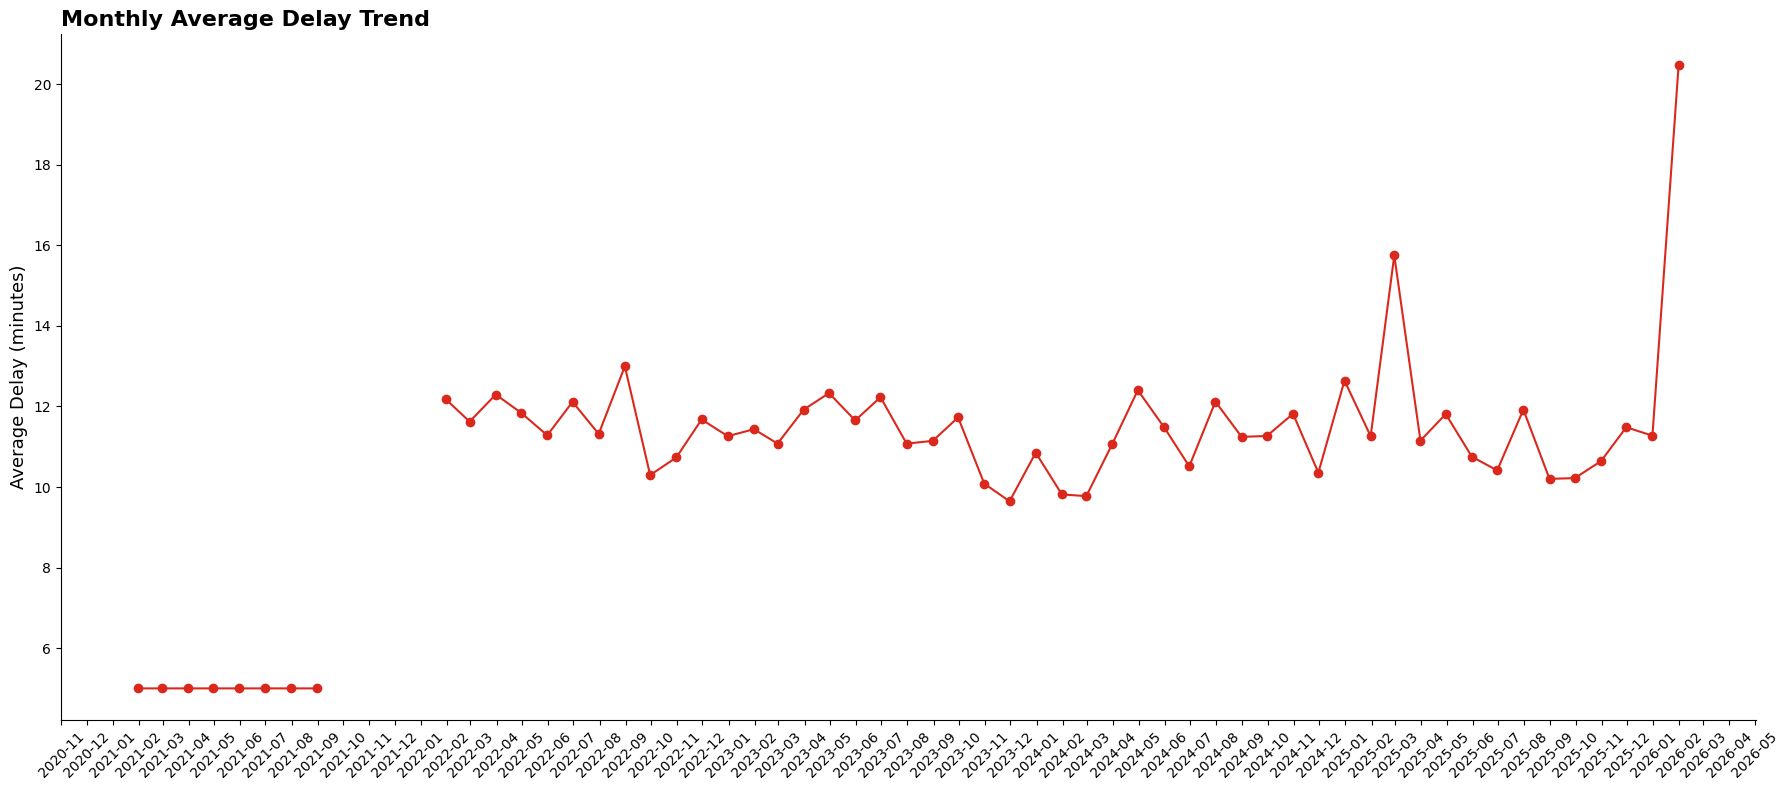

In [31]:
# Monthly aggregation
processed_df["date"] = pd.to_datetime(processed_df["date"])
monthly_delay = (
    processed_df
    .groupby(pd.Grouper(key="date", freq="ME"))["min_delay"]
    .mean()
)

fig, ax = plt.subplots(figsize=(18, 8))
ax.plot(monthly_delay.index, monthly_delay.values, marker="o", color=TTC_RED)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax.set_title("Monthly Average Delay Trend", fontsize=16, fontweight="bold", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Average Delay (minutes)", fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Polished Visualizations for Presentation

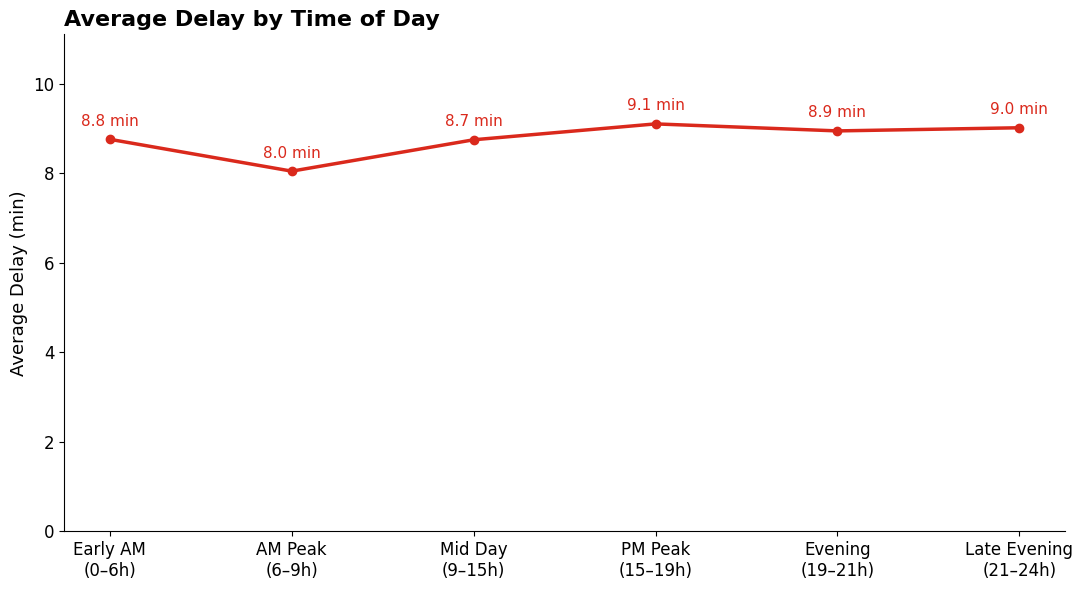

In [36]:
order = ["Early_AM", "AM_Peak", "Mid_Day", "PM_Peak", "Evening", "Late_Evening"]
labels = [
    "Early AM\n(0–6h)",
    "AM Peak\n(6–9h)",
    "Mid Day\n(9–15h)",
    "PM Peak\n(15–19h)",
    "Evening\n(19–21h)",
    "Late Evening\n(21–24h)"
]

avg_delay = (
    processed_df[processed_df["min_delay"] < 30]
    .groupby("time_category")["min_delay"]
    .mean()
    .reindex(order)
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(labels, avg_delay.values, marker="o", linewidth=2.5, color="#DA291C")

for i, val in enumerate(avg_delay.values):
    ax.text(i, val + 0.3, f"{val:.1f} min", ha="center", fontsize=11, color="#DA291C")

ax.set_ylim(0, avg_delay.max() + 2)
ax.set_title("Average Delay by Time of Day", fontsize=16, fontweight="bold", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Average Delay (min)", fontsize=13)
ax.tick_params(axis='both', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### Delays by Direction

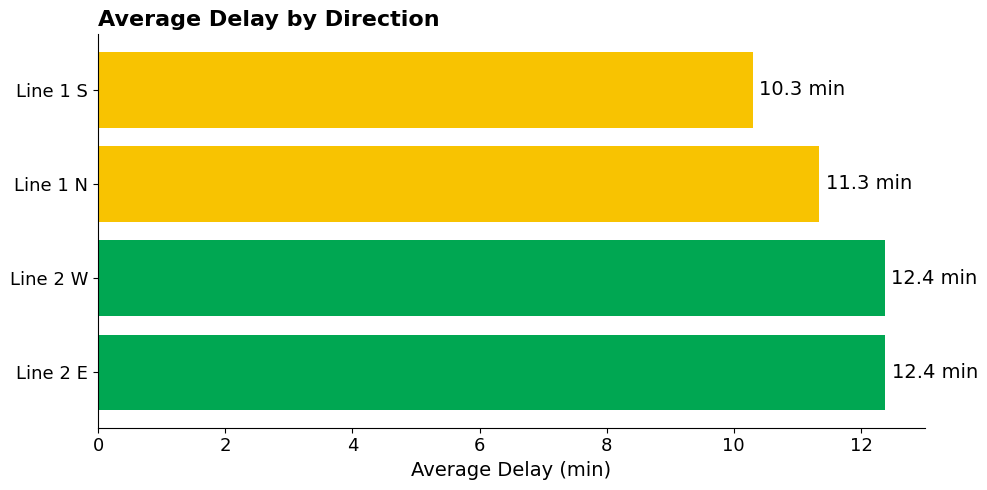

In [37]:
# Average Delay by Direction — TTC line colours
bound_labels = {"E": "Line 2 E", "W": "Line 2 W", "N": "Line 1 N", "S": "Line 1 S"}

bound_stats = (
    processed_df[processed_df["bound"].isin(bound_labels.keys())]
    .groupby("bound")["min_delay"]
    .agg(["mean", "count"])
    .rename(index=bound_labels)
    .sort_values("mean", ascending=False)
)

ttc_line_colors = [LINE_2_GREEN, LINE_2_GREEN, LINE_1_YELLOW, LINE_1_YELLOW]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(bound_stats.index, bound_stats["mean"], color=ttc_line_colors)
ax.set_title("Average Delay by Direction", fontsize=16, fontweight="bold", loc="left")
ax.set_xlabel("Average Delay (min)", fontsize=14)
ax.set_ylabel("")
ax.tick_params(axis='both', labelsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, val in enumerate(bound_stats["mean"]):
    ax.text(val + 0.1, i, f"{val:.1f} min", va="center", fontsize=14)
plt.tight_layout()
plt.show()

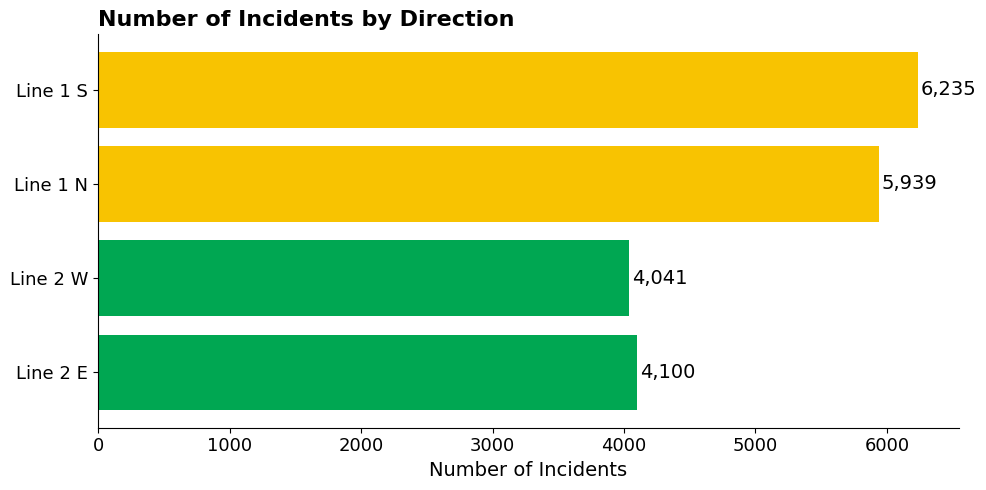

In [38]:
# Number of Incidents by Direction
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(bound_stats.index, bound_stats["count"], color=ttc_line_colors)
ax.set_title("Number of Incidents by Direction", fontsize=16, fontweight="bold", loc="left")
ax.set_xlabel("Number of Incidents", fontsize=14)
ax.set_ylabel("")
ax.tick_params(axis='both', labelsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, val in enumerate(bound_stats["count"]):
    ax.text(val + 20, i, f"{val:,}", va="center", fontsize=14)
plt.tight_layout()
plt.show()

### Station Analysis

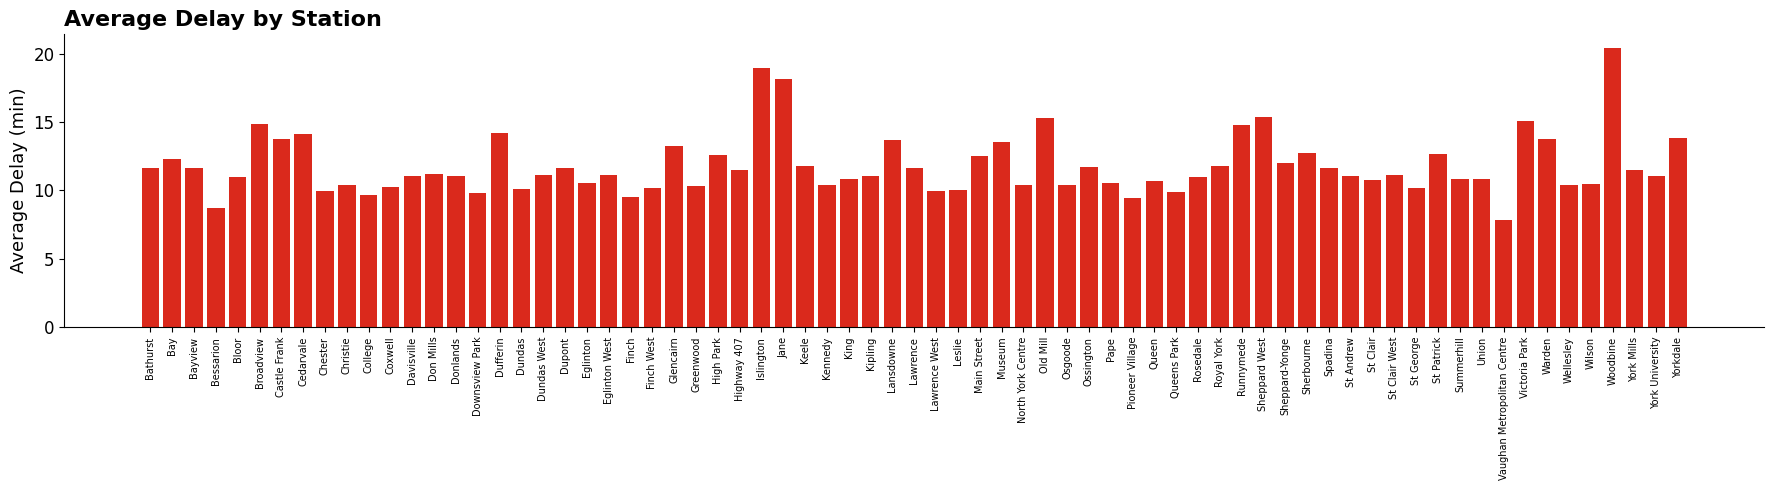

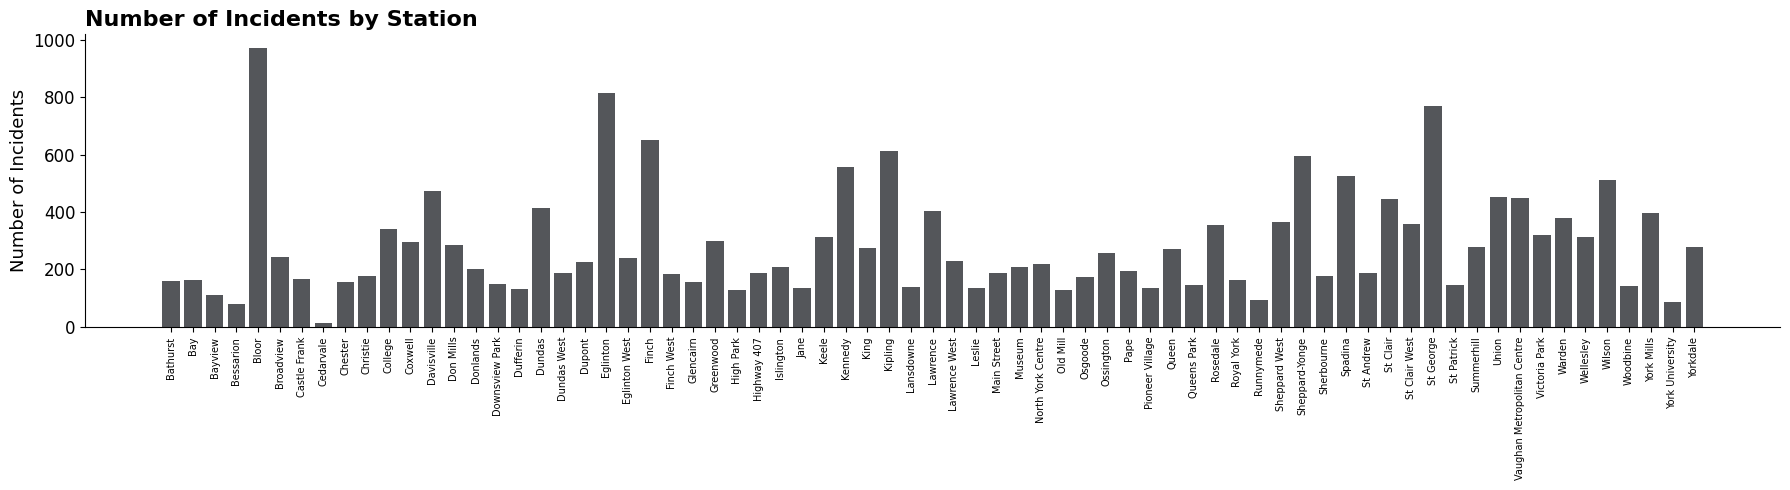

In [46]:
processed_df["station"] = processed_df["station"].str.title()


station_stats = (
    processed_df.groupby("station")["min_delay"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_delay", "count": "incidents"})
)

top5_avg = station_stats.nlargest(5, "avg_delay")
top5_incidents = station_stats.nlargest(5, "incidents")

# 1. All stations — average delay
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(station_stats.index, station_stats["avg_delay"], color= TTC_RED)
ax.set_title("Average Delay by Station", fontsize=16, fontweight="bold", loc="left")
ax.set_ylabel("Average Delay (min)", fontsize=13)
ax.set_xlabel("")
ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# 2. All stations — number of incidents
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(station_stats.index, station_stats["incidents"], color= TTC_DARK)
ax.set_title("Number of Incidents by Station", fontsize=16, fontweight="bold", loc="left")
ax.set_ylabel("Number of Incidents", fontsize=13)
ax.set_xlabel("")
ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()




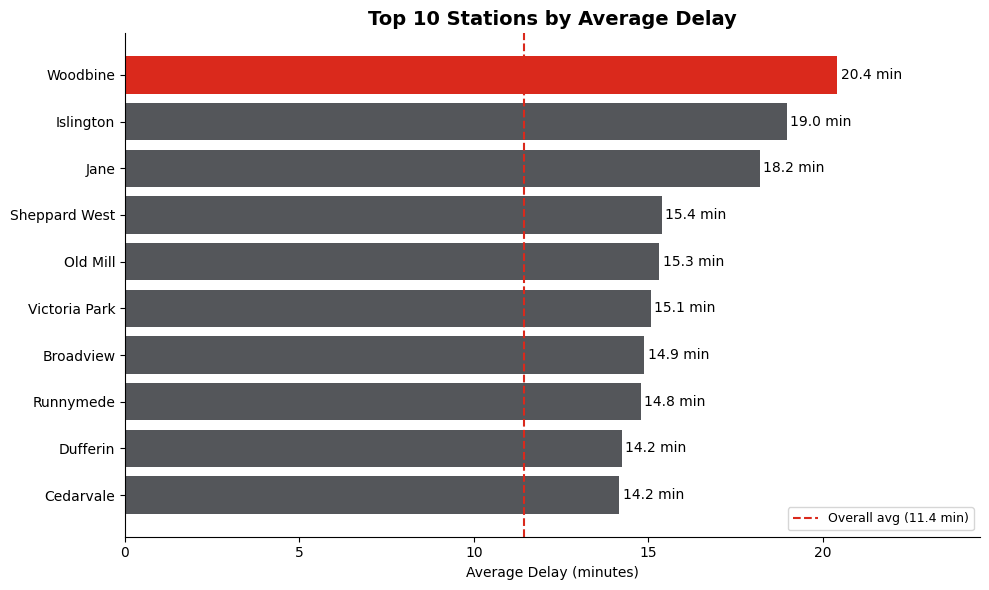

In [47]:
# Top 10 Stations by Average Delay 

top10_stations = (processed_df.groupby("station")["min_delay"]
                  .mean()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [TTC_RED if i == 0 else TTC_DARK for i in range(len(top10_stations))]
bars = ax.barh(top10_stations.index[::-1], top10_stations.values[::-1], color=colors[::-1])

for bar, val in zip(bars, top10_stations.values[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} min", va="center", fontsize=10)

ax.set_title("Top 10 Stations by Average Delay", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Delay (minutes)")
ax.axvline(x=processed_df["min_delay"].mean(), color=TTC_RED,
           linestyle="--", linewidth=1.5, label=f"Overall avg ({processed_df['min_delay'].mean():.1f} min)")
ax.legend(fontsize=9)
ax.set_xlim(0, top10_stations.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("top10_stations.png", dpi=150, bbox_inches="tight")
plt.show()

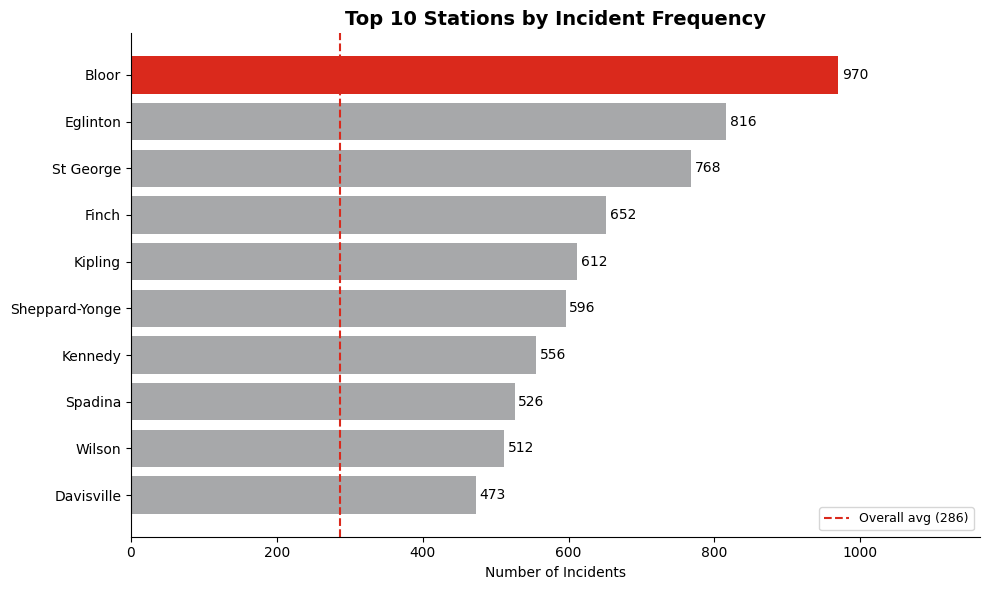

In [48]:
# Top 10 Stations by Incident Frequency

top10_freq = (processed_df.groupby("station")["min_delay"]
              .count()
              .sort_values(ascending=False)
              .head(10))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [TTC_RED if i == 0 else TTC_GREY for i in range(len(top10_freq))]
bars = ax.barh(top10_freq.index[::-1], top10_freq.values[::-1], color=colors[::-1])

for bar, val in zip(bars, top10_freq.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=10)

ax.set_title("Top 10 Stations by Incident Frequency", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Incidents")
ax.axvline(x=processed_df.groupby("station").size().mean(), color=TTC_RED,
           linestyle="--", linewidth=1.5, label=f"Overall avg ({processed_df.groupby('station').size().mean():.0f})")
ax.legend(fontsize=9)
ax.set_xlim(0, top10_freq.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

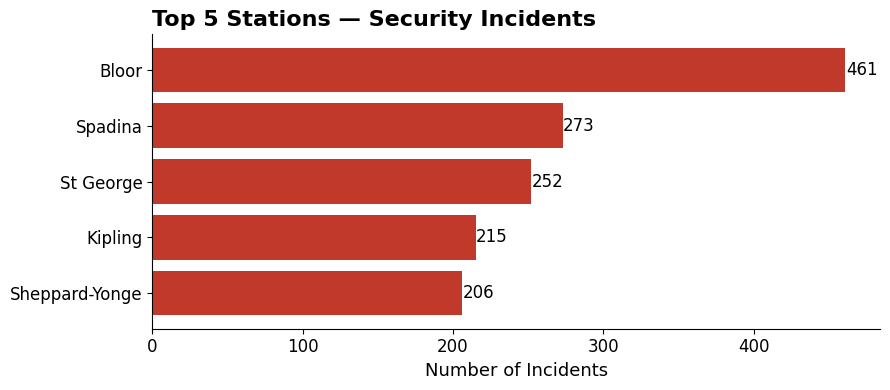

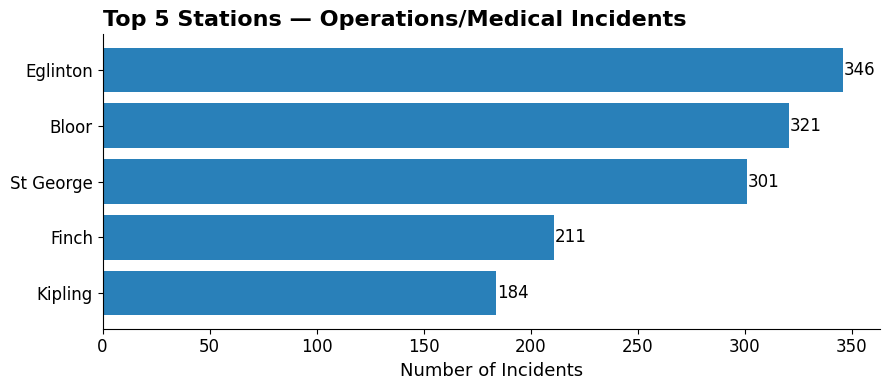

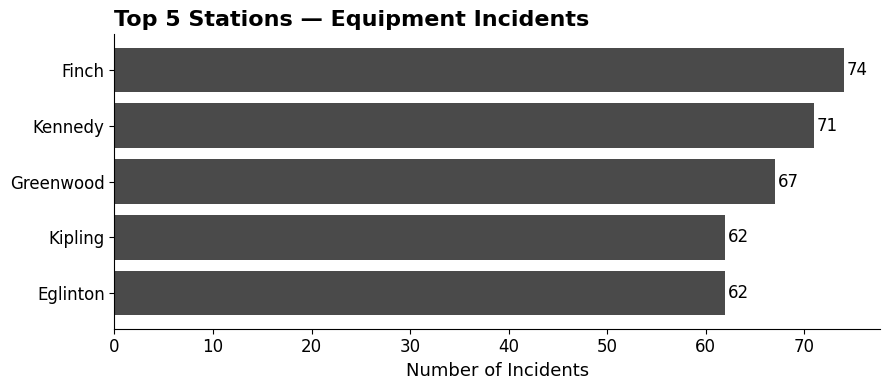

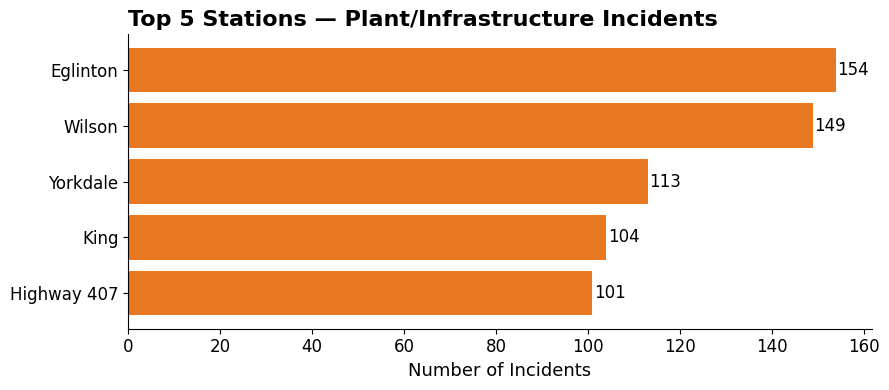

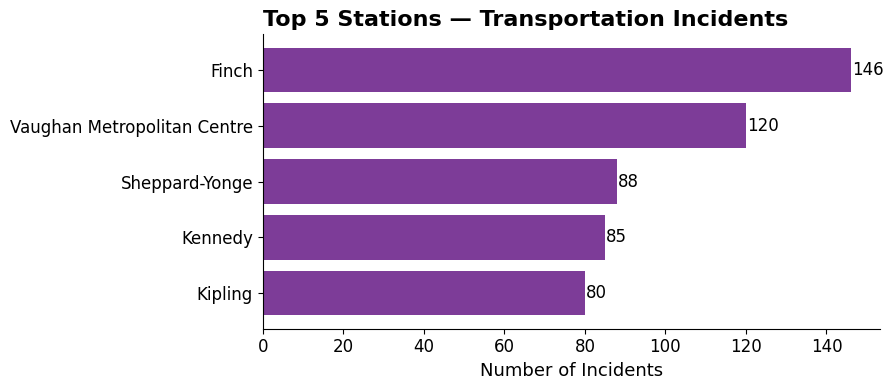

In [49]:


# 5-category scheme: grouped by delay code prefix
def get_code_category(code):
    code = str(code).upper()
    if code.startswith('EU'):   return 'Equipment'
    elif code.startswith('MU'): return 'Operations/Medical'
    elif code.startswith('PU'): return 'Plant/Infrastructure'
    elif code.startswith('SU'): return 'Security'
    elif code.startswith('TU'): return 'Transportation'
    else:                       return 'Other'

processed_df["incident_type"] = processed_df["code"].apply(get_code_category)

incident_types = list(INCIDENT_COLORS.keys())

for incident in incident_types:
    top5 = (
        processed_df[processed_df["incident_type"] == incident]
        .groupby("station")
        .size()
        .nlargest(5)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(top5.index, top5.values, color=INCIDENT_COLORS[incident])
    ax.set_title(f"Top 5 Stations — {incident} Incidents", fontsize=16, fontweight="bold", loc="left")
    ax.set_xlabel("Number of Incidents", fontsize=13)
    ax.tick_params(axis='both', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, val in enumerate(top5.values):
        ax.text(val + 0.3, i, f"{val:,}", va="center", fontsize=12)
    plt.tight_layout()
    plt.show()

### Incident Type Analysis — Top Stations by Count

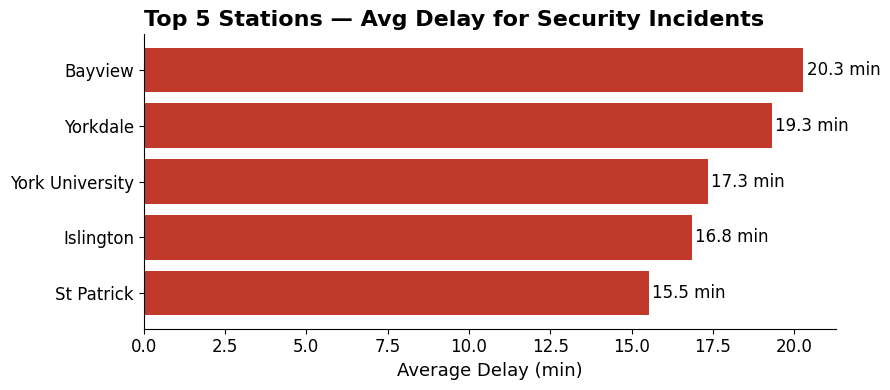

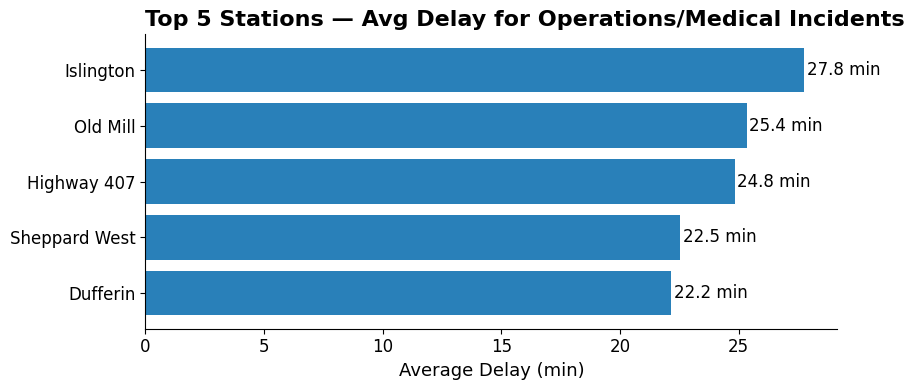

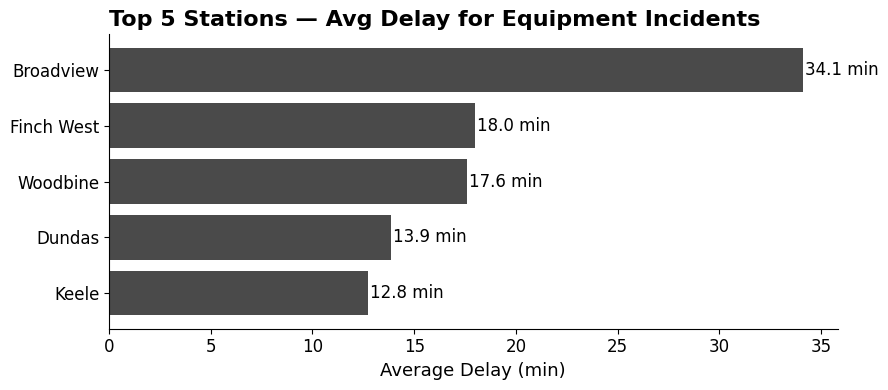

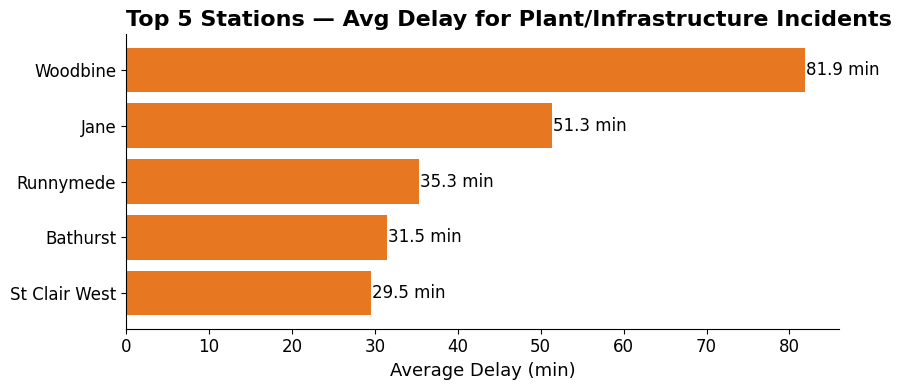

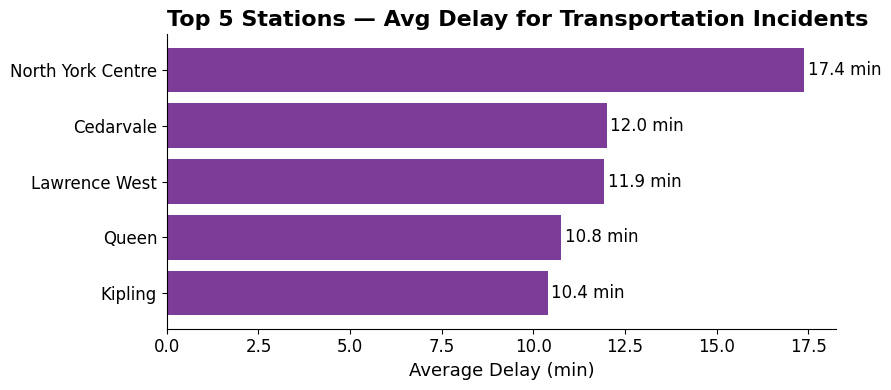

In [50]:
for incident in incident_types:
    top5 = (
        processed_df[processed_df["incident_type"] == incident]
        .groupby("station")["min_delay"]
        .mean()
        .nlargest(5)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(top5.index, top5.values, color=INCIDENT_COLORS[incident])
    ax.set_title(f"Top 5 Stations — Avg Delay for {incident} Incidents", fontsize=16, fontweight="bold", loc="left")
    ax.set_xlabel("Average Delay (min)", fontsize=13)
    ax.tick_params(axis='both', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, val in enumerate(top5.values):
        ax.text(val + 0.1, i, f"{val:.1f} min", va="center", fontsize=12)
    plt.tight_layout()
    plt.show()

### Delay Categories: Volume vs Severity

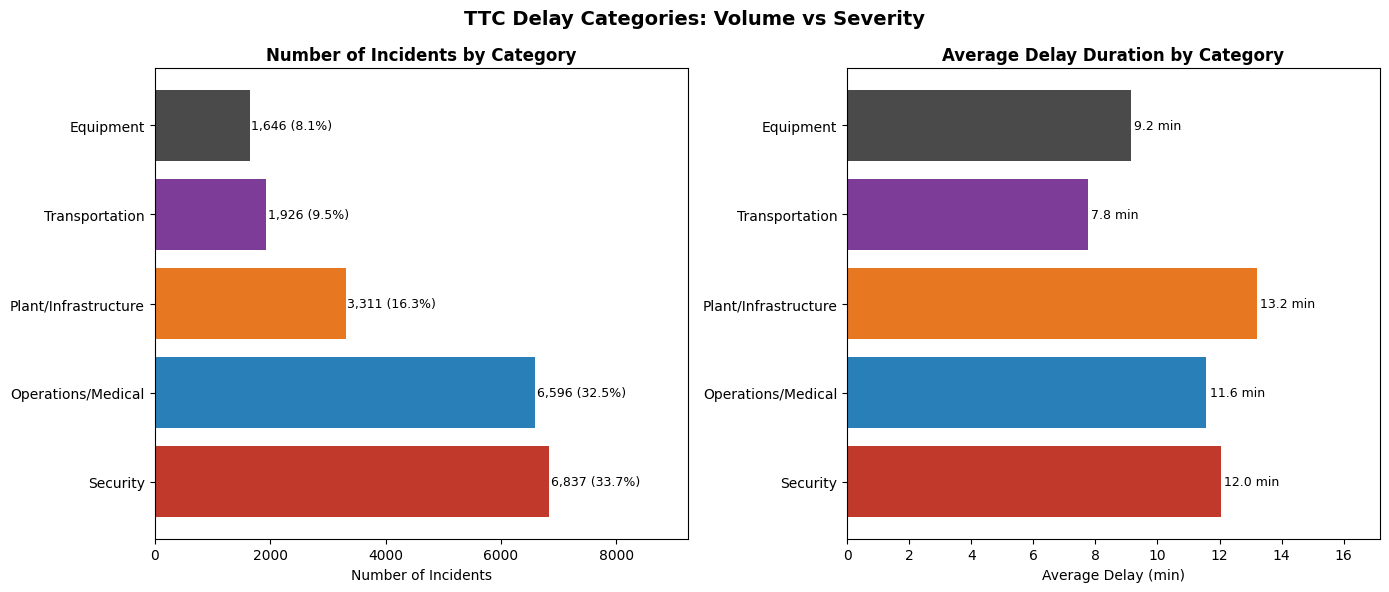

In [51]:
# Delay Categories: Volume vs Severity
cat_stats = (
    processed_df.groupby('incident_type')['min_delay']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
)

# Pull colours from INCIDENT_COLORS — same palette as incident type charts
cat_colors = [INCIDENT_COLORS.get(cat, TTC_GREY) for cat in cat_stats.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].barh(cat_stats.index, cat_stats['count'], color=cat_colors)
axes[0].set_title('Number of Incidents by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Incidents')
for bar, val in zip(bars1, cat_stats['count']):
    axes[0].text(val + 30, bar.get_y() + bar.get_height() / 2,
                 f'{val:,} ({val / len(processed_df) * 100:.1f}%)',
                 va='center', fontsize=9)
axes[0].set_xlim(0, cat_stats['count'].max() * 1.35)

bars2 = axes[1].barh(cat_stats.index, cat_stats['mean'], color=cat_colors)
axes[1].set_title('Average Delay Duration by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Delay (min)')
for bar, val in zip(bars2, cat_stats['mean']):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f} min', va='center', fontsize=9)
axes[1].set_xlim(0, cat_stats['mean'].max() * 1.3)

plt.suptitle('TTC Delay Categories: Volume vs Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

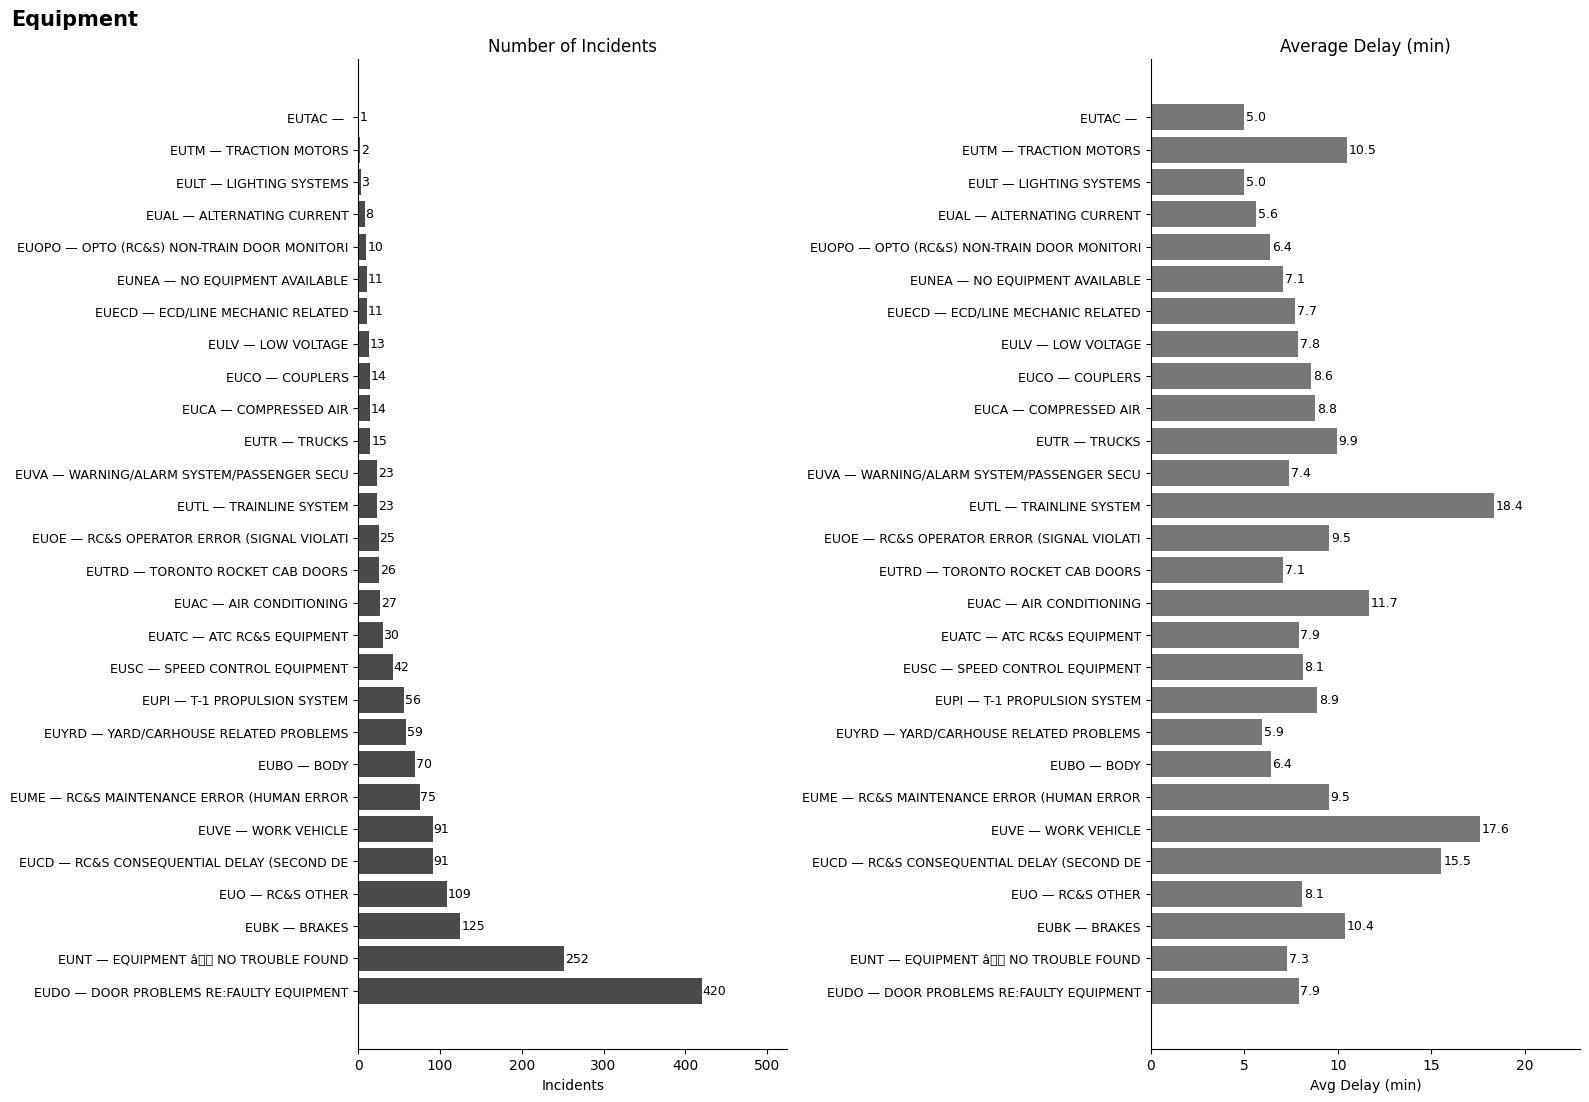

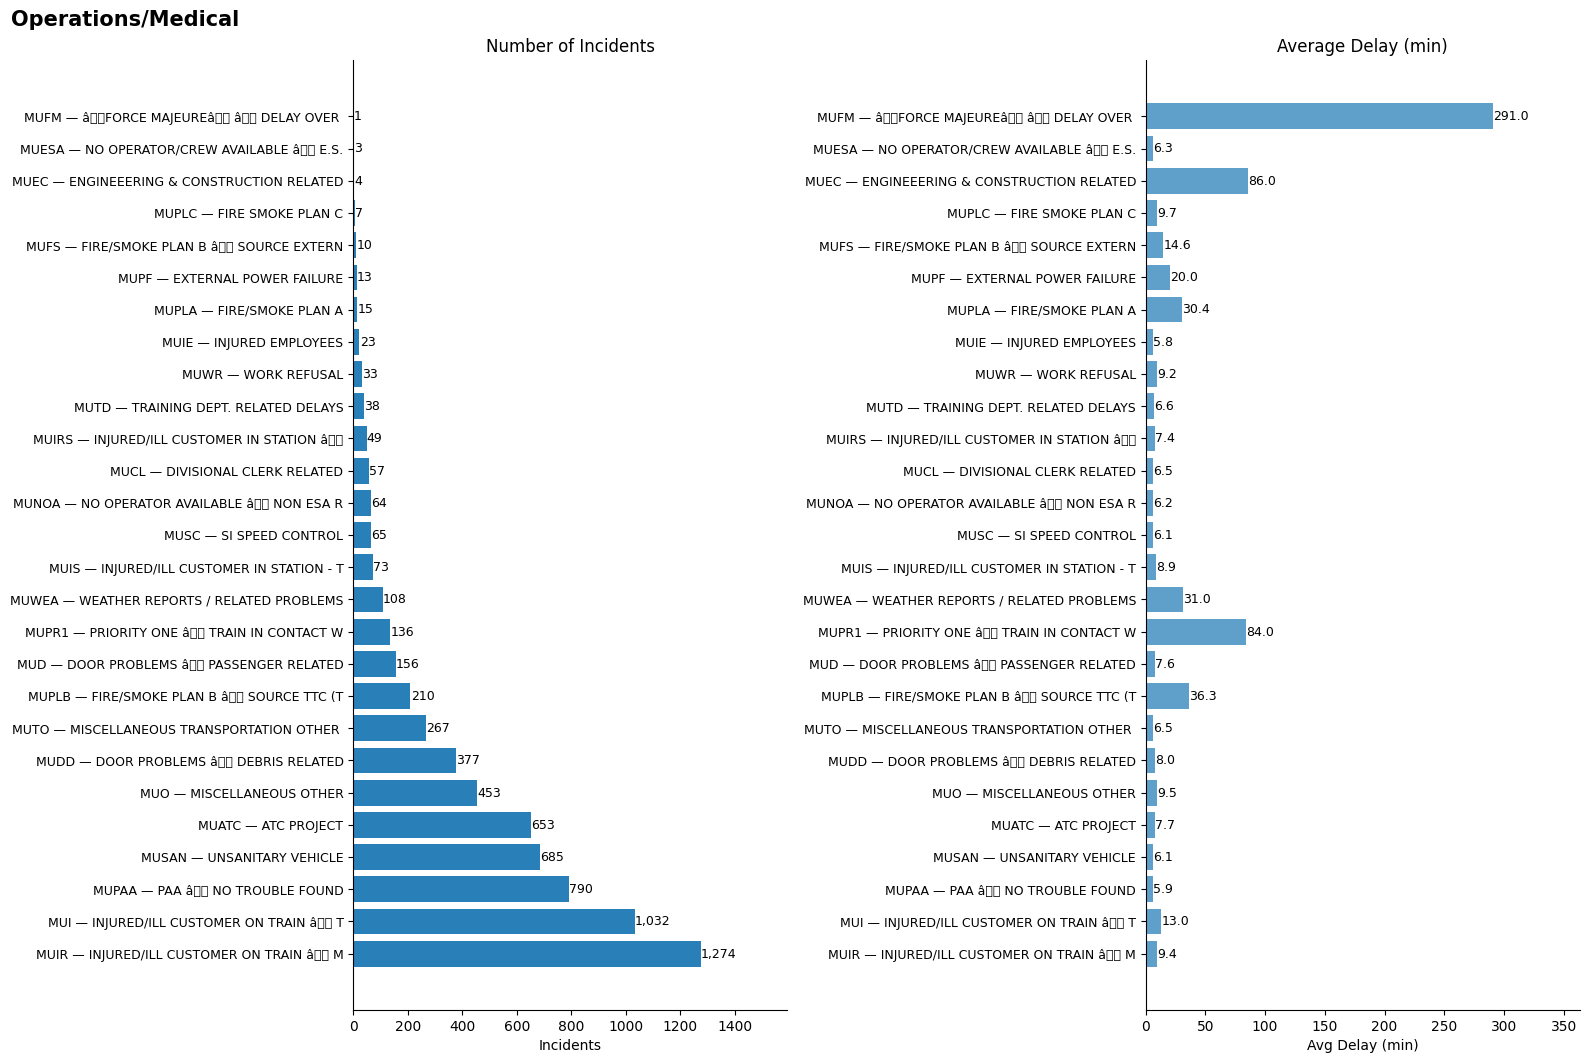

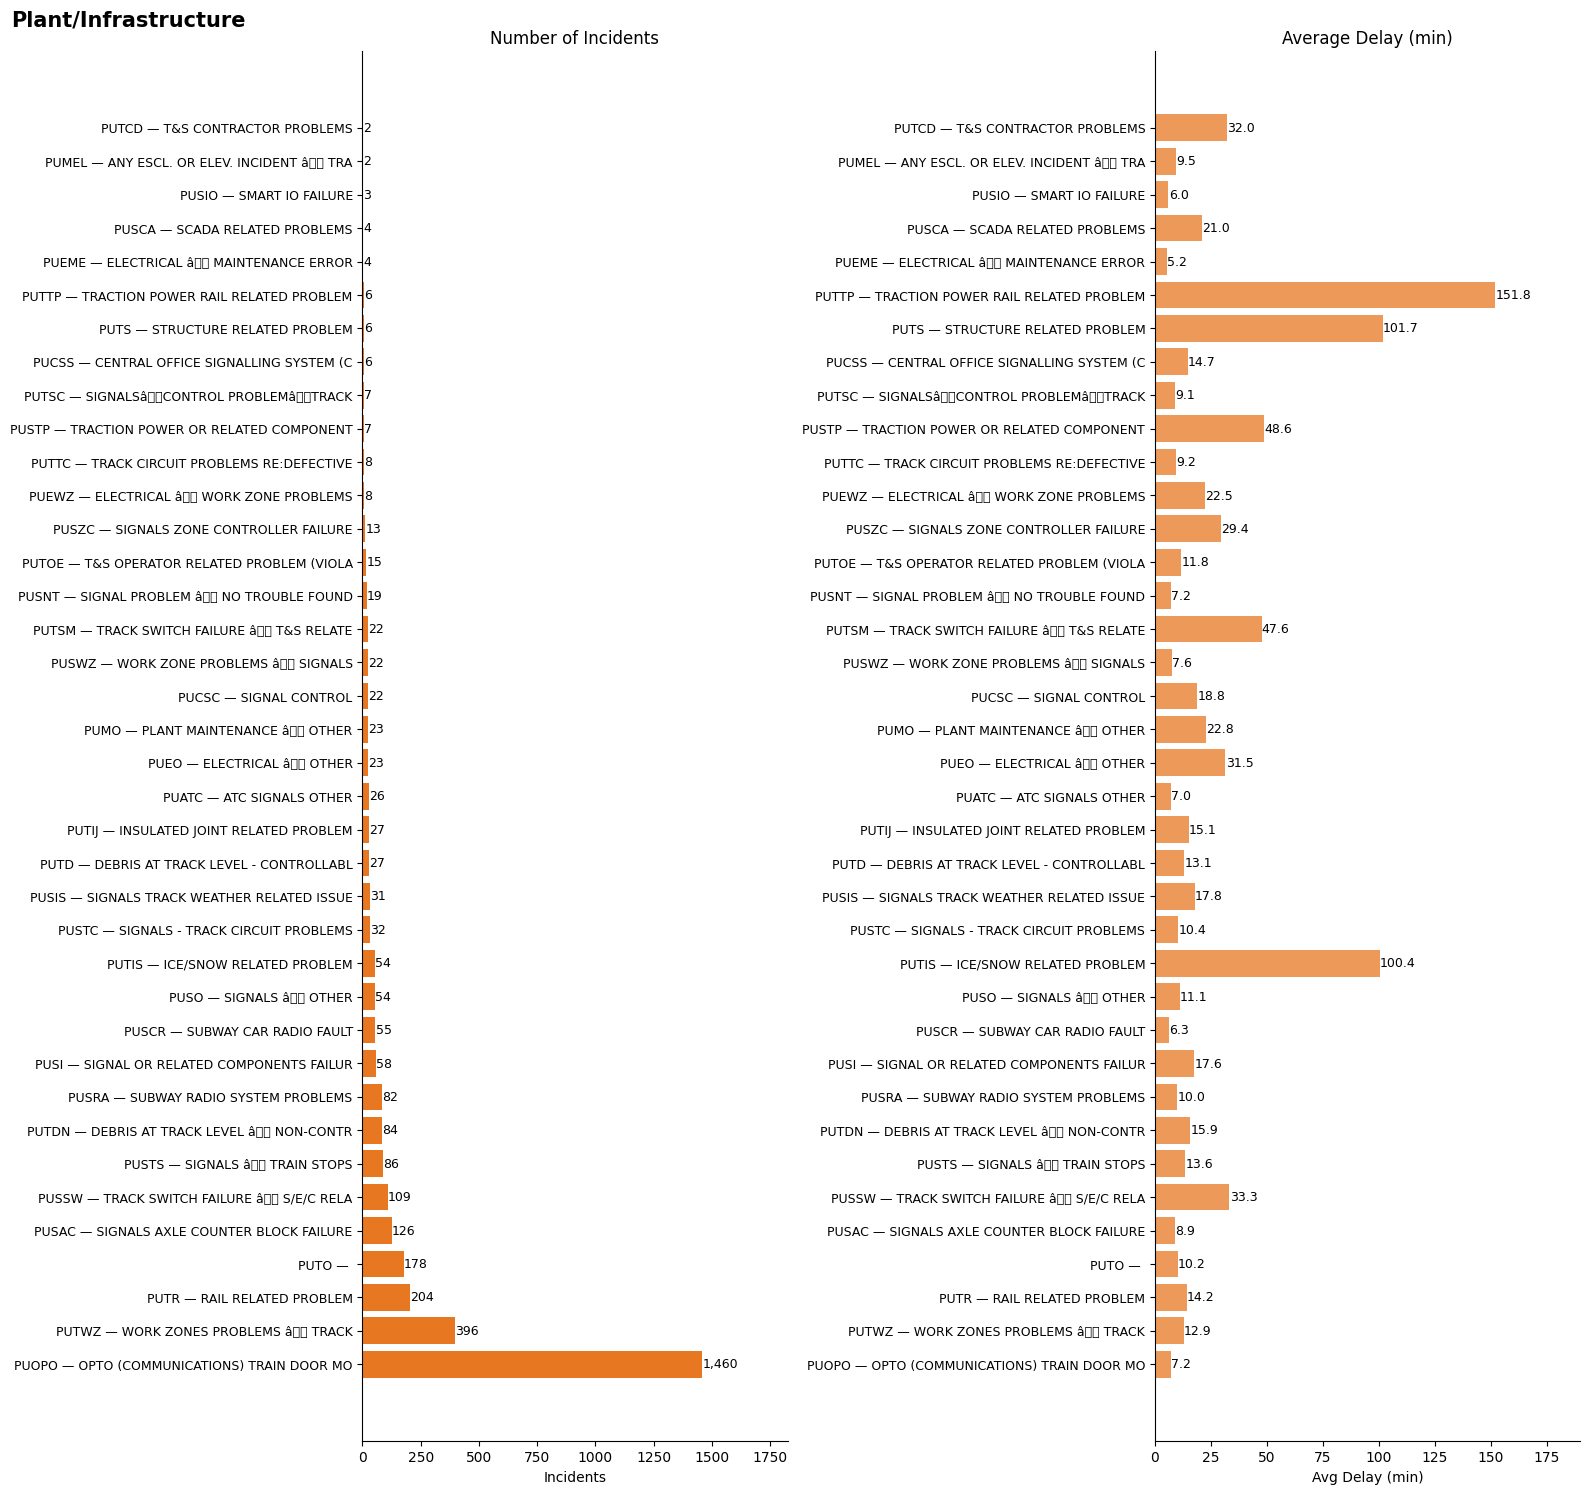

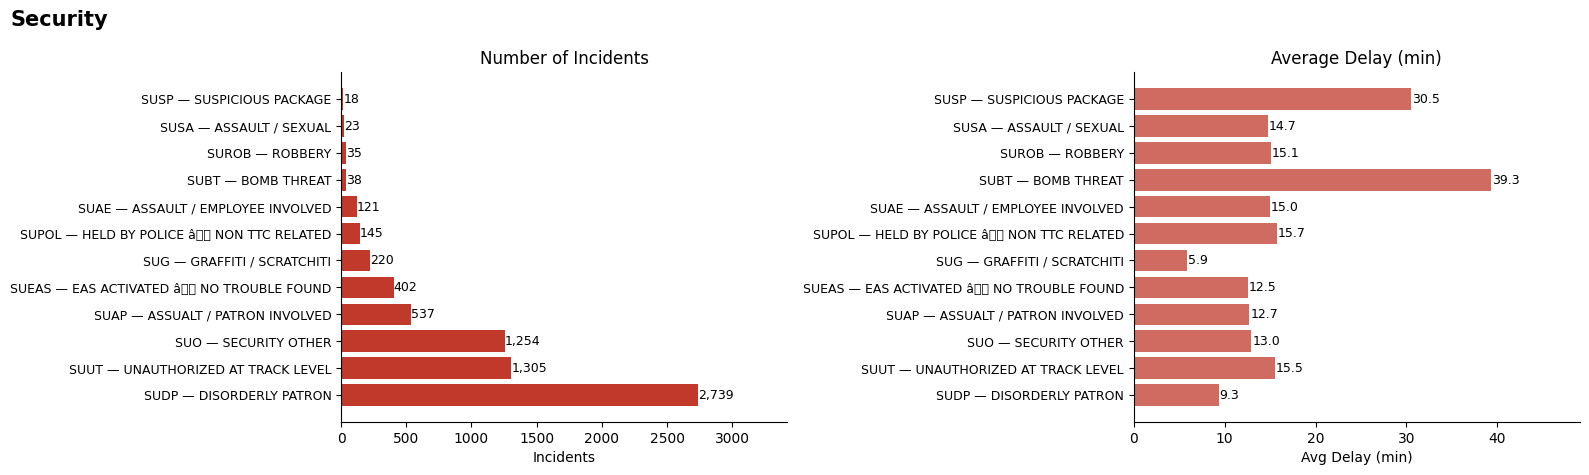

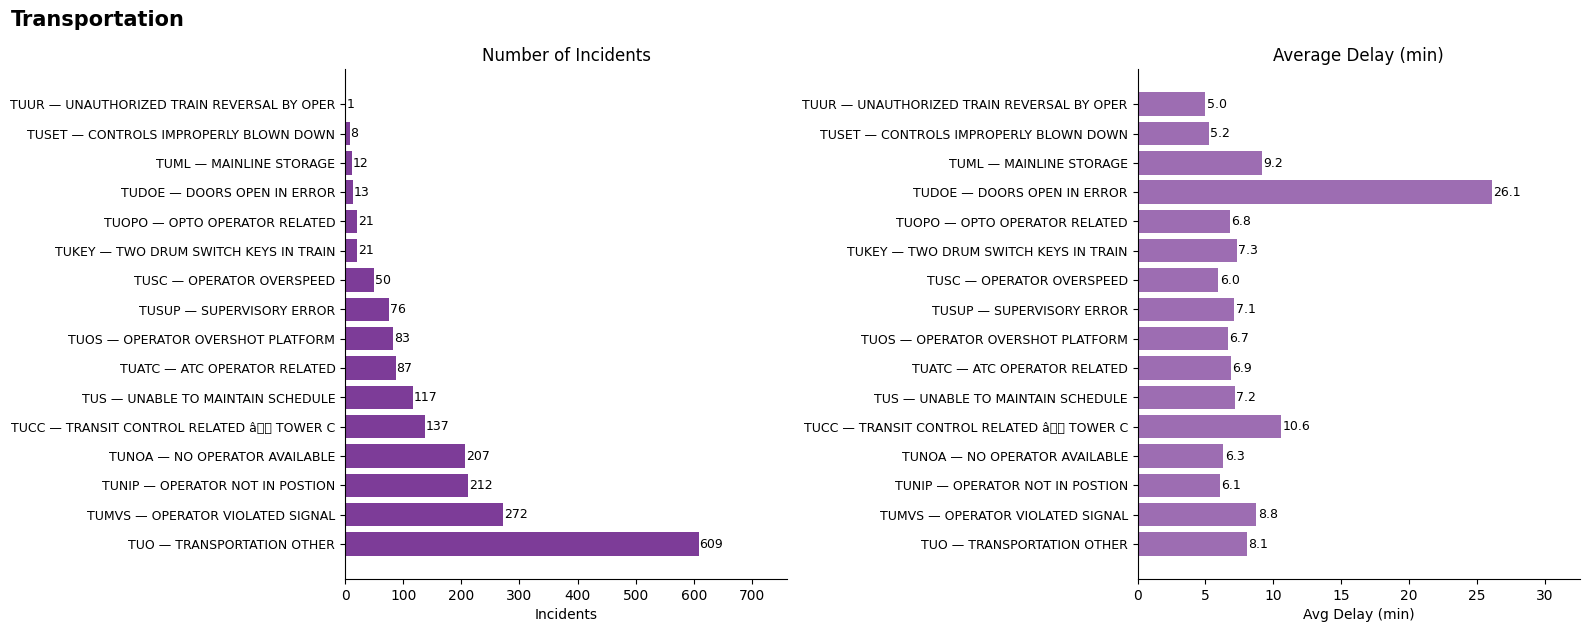

In [52]:
# Deep dive — all codes within each category, incidents and average delay
code_detail = (
    processed_df.groupby(['incident_type', 'code'])['min_delay']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'incidents', 'mean': 'avg_delay_min'})
    .round(2)
    .reset_index()
    .merge(code_description_df[['code', 'description']], on='code', how='left')
    .sort_values(['incident_type', 'incidents'], ascending=[True, False])
)

for category in sorted(code_detail['incident_type'].unique()):
    df_cat = code_detail[code_detail['incident_type'] == category].copy()
    color = INCIDENT_COLORS.get(category, TTC_GREY)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(df_cat) * 0.4)))
    fig.suptitle(f"{category}", fontsize=15, fontweight='bold', x=0.01, ha='left')

    labels = [
        f"{row['code']} — {row['description'][:35] if pd.notna(row['description']) else ''}"
        for _, row in df_cat.iterrows()
    ]

    # Left: incident count
    axes[0].barh(labels, df_cat['incidents'], color=color)
    axes[0].set_title('Number of Incidents', fontsize=12)
    axes[0].set_xlabel('Incidents')
    axes[0].tick_params(axis='y', labelsize=9)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    for i, val in enumerate(df_cat['incidents']):
        axes[0].text(val + 1, i, f"{val:,}", va="center", fontsize=9)
    axes[0].set_xlim(0, df_cat['incidents'].max() * 1.25)

    # Right: average delay
    axes[1].barh(labels, df_cat['avg_delay_min'], color=color, alpha=0.75)
    axes[1].set_title('Average Delay (min)', fontsize=12)
    axes[1].set_xlabel('Avg Delay (min)')
    axes[1].tick_params(axis='y', labelsize=9)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    for i, val in enumerate(df_cat['avg_delay_min']):
        axes[1].text(val + 0.1, i, f"{val:.1f}", va="center", fontsize=9)
    axes[1].set_xlim(0, df_cat['avg_delay_min'].max() * 1.25)

    plt.tight_layout()
    plt.show()

---
## Key Findings

| Finding | Detail |
|---|---|
| **Most common cause** | Disorderly Patron (`SUDP`) — 2,739 incidents (13.5%) |
| **Most severe cause** | Ice/Snow (`PUTIS`) — avg 100 min delay |
| **Highest delay station** | Woodbine — avg 20.4 min |
| **Most incident-prone station** | Bloor — 970 incidents |
| **Worst line** | BD (Bloor-Danforth) — avg 12.5 min vs YU 10.8 min |
| **Worst direction** | Eastbound (Line 2) and Westbound (Line 2) — avg ~12.4 min |
| **Peak time** | PM Peak — avg ~9.1 min (excluding extreme outliers) |
| **Delay-Gap correlation** | 0.88 — strong signal; `min_gap` is a valuable feature |
| **Category by volume** | Operations/Medical (36%), Plant/Infrastructure (25%), Security (18%) |
| **Category by severity** | Plant/Infrastructure has highest avg delay duration |